### EDA

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

In [2]:
import os

data_dir = "/kaggle/input/cloud-masking-dataset/content/train/data"
mask_dir = "/kaggle/input/cloud-masking-dataset/content/train/masks"

image_files = sorted([f for f in os.listdir(data_dir) if f.endswith('.tif')])
mask_files = sorted([f for f in os.listdir(mask_dir) if f.endswith('.tif')])

print(f"Total Images: {len(image_files)}")
print(f"Total Masks: {len(mask_files)}")


Total Images: 10573
Total Masks: 10573


In [3]:
missing_masks = [img for img in image_files if img not in mask_files]

if missing_masks:
    print(f"Missing masks for {len(missing_masks)} images:")
    print(missing_masks[:10])  # Print first 10 missing masks
else:
    print("All images have corresponding masks.")


All images have corresponding masks.


In [4]:
!!pip install earthpy gdal

['Collecting earthpy',
 '  Downloading earthpy-0.9.4-py3-none-any.whl.metadata (9.2 kB)',
 'Requirement already satisfied: gdal in /usr/local/lib/python3.11/dist-packages (3.6.4)',
 'Requirement already satisfied: geopandas in /usr/local/lib/python3.11/dist-packages (from earthpy) (0.14.4)',
 'Requirement already satisfied: matplotlib>=2.0.0 in /usr/local/lib/python3.11/dist-packages (from earthpy) (3.7.5)',
 'Requirement already satisfied: numpy>=1.14.0 in /usr/local/lib/python3.11/dist-packages (from earthpy) (1.26.4)',
 'Collecting rasterio (from earthpy)',
 '  Downloading rasterio-1.4.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (9.1 kB)',
 'Requirement already satisfied: scikit-image in /usr/local/lib/python3.11/dist-packages (from earthpy) (0.25.1)',
 'Requirement already satisfied: requests in /usr/local/lib/python3.11/dist-packages (from earthpy) (2.32.3)',
 'Requirement already satisfied: contourpy>=1.0.1 in /usr/local/lib/python3.11/dist-packages (fro

Number of bands of the image= 4


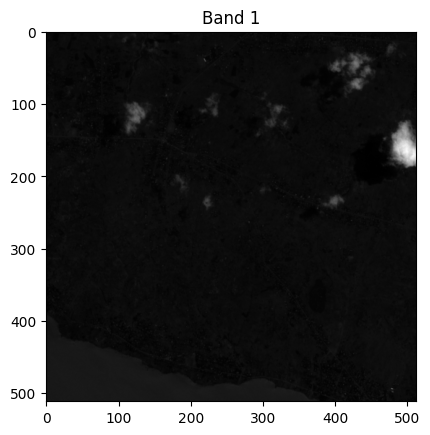

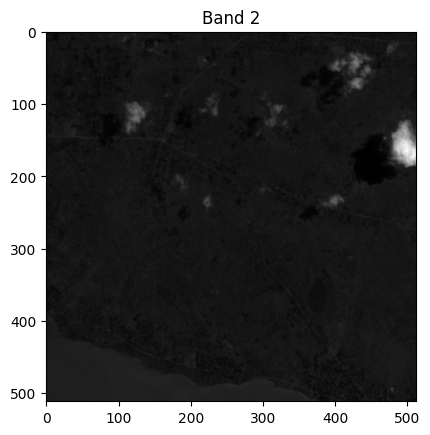

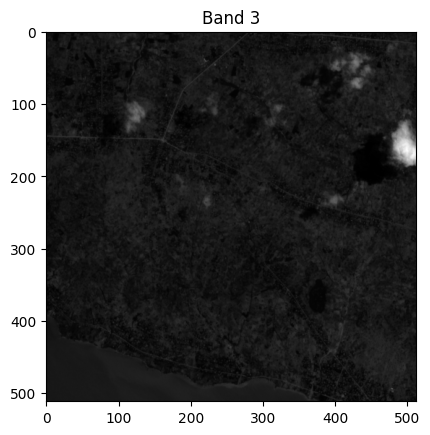

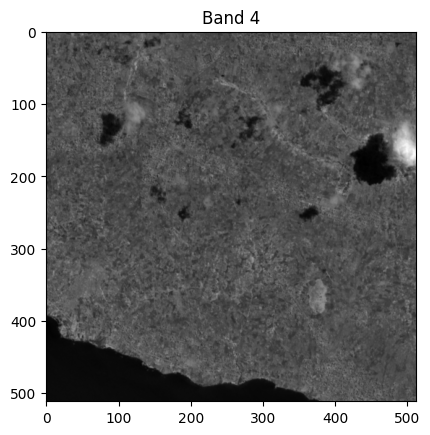

Number of bands of the image= 1


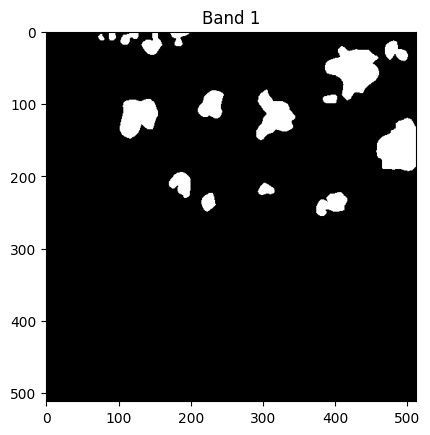

In [5]:
import numpy as np
from sklearn import cluster
from osgeo import gdal, gdal_array
import matplotlib.pyplot as plt
import earthpy.plot as ep
import earthpy.spatial as es
gdal.UseExceptions()
gdal.AllRegister()
##This line should be updated with the name and path of the image
img_ds = gdal.Open('/kaggle/input/cloud-masking-dataset/content/train/data/100177.tif', gdal.GA_ReadOnly)

num_bands=img_ds.RasterCount
print("Number of bands of the image= "+str(num_bands))

##Plot the image band by band i.e: each image is the visualization of a single band
##Note python is zero indexed and bands start from 1
for i in range(1,num_bands+1):
  band = img_ds.GetRasterBand(i)
  img = band.ReadAsArray()
  # Plot the image using Matplotlib
  plt.title("Band "+str(i))
  plt.imshow(img, cmap='gray')
  plt.show()
##This line should be updated with the name and path of the image
mask = gdal.Open('/kaggle/input/cloud-masking-dataset/content/train/masks/100177.tif', gdal.GA_ReadOnly)

num_bands=mask.RasterCount
print("Number of bands of the image= "+str(num_bands))

##Plot the image band by band i.e: each image is the visualization of a single band
##Note python is zero indexed and bands start from 1
for i in range(1,num_bands+1):
  band = mask.GetRasterBand(i)
  img = band.ReadAsArray()
  # Plot the image using Matplotlib
  plt.title("Band "+str(i))
  plt.imshow(img, cmap='gray')
  plt.show()



/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


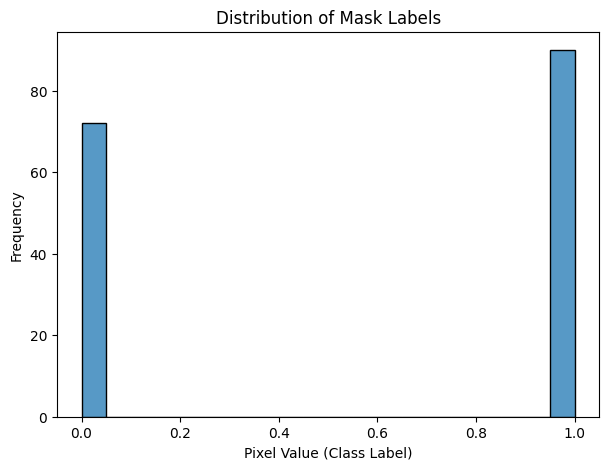

Unique values in masks: {0, 1}


In [6]:
import numpy as np

mask_values = []

for file in mask_files[:100]:  # Analyze first 100 masks
    mask = np.array(Image.open(os.path.join(mask_dir, file)))
    unique_values = np.unique(mask)
    mask_values.extend(unique_values.tolist())

# Plot histogram of mask pixel values
plt.figure(figsize=(7, 5))
sns.histplot(mask_values, bins=20, kde=False)
plt.xlabel("Pixel Value (Class Label)")
plt.ylabel("Frequency")
plt.title("Distribution of Mask Labels")
plt.show()

print(f"Unique values in masks: {set(mask_values)}")


### Analyze the distribution of images, including counts of fully clouded, partially cloudy, and cloud-free images.

In [7]:
import os
import numpy as np
from osgeo import gdal

# Path to masks directory
mask_dir = '/kaggle/input/cloud-masking-dataset/content/train/masks'
mask_files = [f for f in os.listdir(mask_dir) if f.endswith('.tif')]

# Thresholds (can tweak as needed)
full_cloud_thresh = 0.98   # 98%+ pixels are cloud
cloud_free_thresh = 0.02   # <2% pixels are cloud

# Counters
full_cloud = 0
partial_cloud = 0
cloud_free = 0

for fname in mask_files:
    mask_path = os.path.join(mask_dir, fname)
    ds = gdal.Open(mask_path, gdal.GA_ReadOnly)
    mask = ds.ReadAsArray()

    total_pixels = mask.size
    cloud_pixels = np.sum(mask > 0)
    cloud_ratio = cloud_pixels / total_pixels

    if cloud_ratio >= full_cloud_thresh:
        full_cloud += 1
    elif cloud_ratio <= cloud_free_thresh:
        cloud_free += 1
    else:
        partial_cloud += 1

# Print results
print("----- Cloud Coverage Distribution -----")
print(f"Total images        : {len(mask_files)}")
print(f"Fully Cloudy        : {full_cloud}")
print(f"Partially Cloudy    : {partial_cloud}")
print(f"Cloud-Free          : {cloud_free}")

----- Cloud Coverage Distribution -----
Total images        : 10573
Fully Cloudy        : 3536
Partially Cloudy    : 6051
Cloud-Free          : 986


### Correlation between bands for single image

Random image selected: 616935.tif
Image shape: (4, 512, 512) (bands, height, width)
(4, 262144)


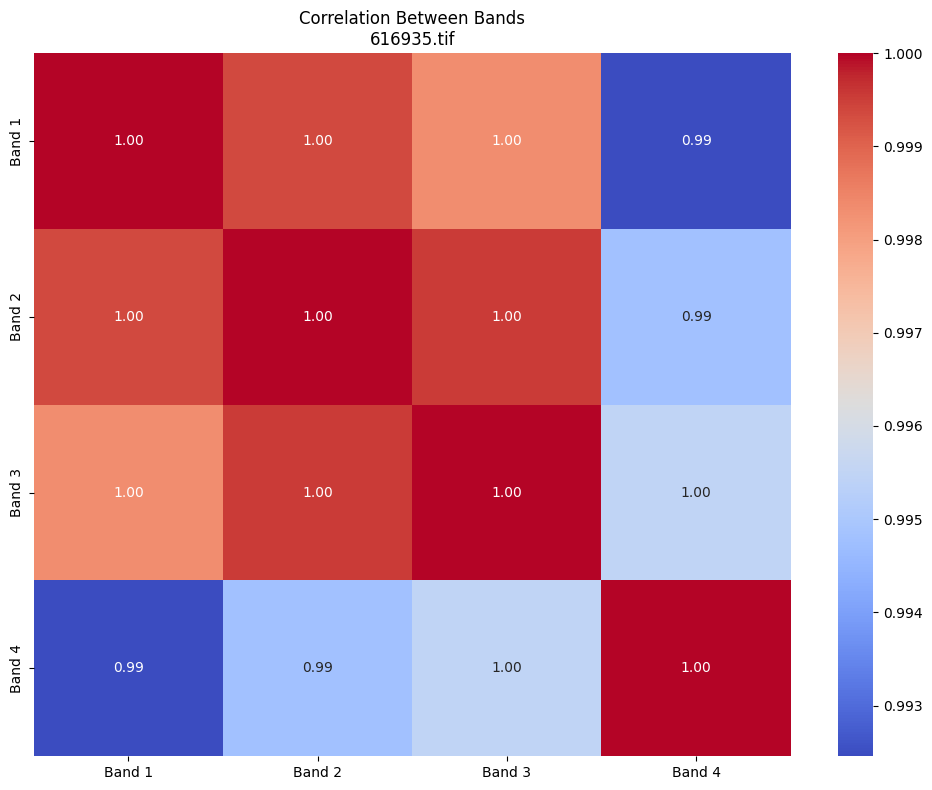

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from osgeo import gdal
import random

# Path to your image directory
image_dir = '/kaggle/input/cloud-masking-dataset/content/train/data'

# Get all .tif files
image_files = [f for f in os.listdir(image_dir) if f.endswith('.tif')]

# Pick a random image
random_image = random.choice(image_files)
image_path = os.path.join(image_dir, random_image)

# Load image
ds = gdal.Open(image_path, gdal.GA_ReadOnly)
img_array = ds.ReadAsArray()  # Shape: (bands, H, W)

# Print image shape
print(f"Random image selected: {random_image}")
print(f"Image shape: {img_array.shape} (bands, height, width)")

# Flatten spatial dimensions to (bands, H*W)
bands, H, W = img_array.shape
# 3,3,2->18
# 2, 9
flattened = img_array.reshape(bands, -1)
print(flattened.shape)
# Compute correlation matrix
corr_matrix = np.corrcoef(flattened)

# Plot correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm',
            xticklabels=[f'Band {i+1}' for i in range(bands)],
            yticklabels=[f'Band {i+1}' for i in range(bands)])
plt.title(f'Correlation Between Bands\n{random_image}')
plt.tight_layout()
plt.show()

### Average Correlation between bands for all images

Processing images: 100%|██████████| 10573/10573 [10:04<00:00, 17.50it/s]


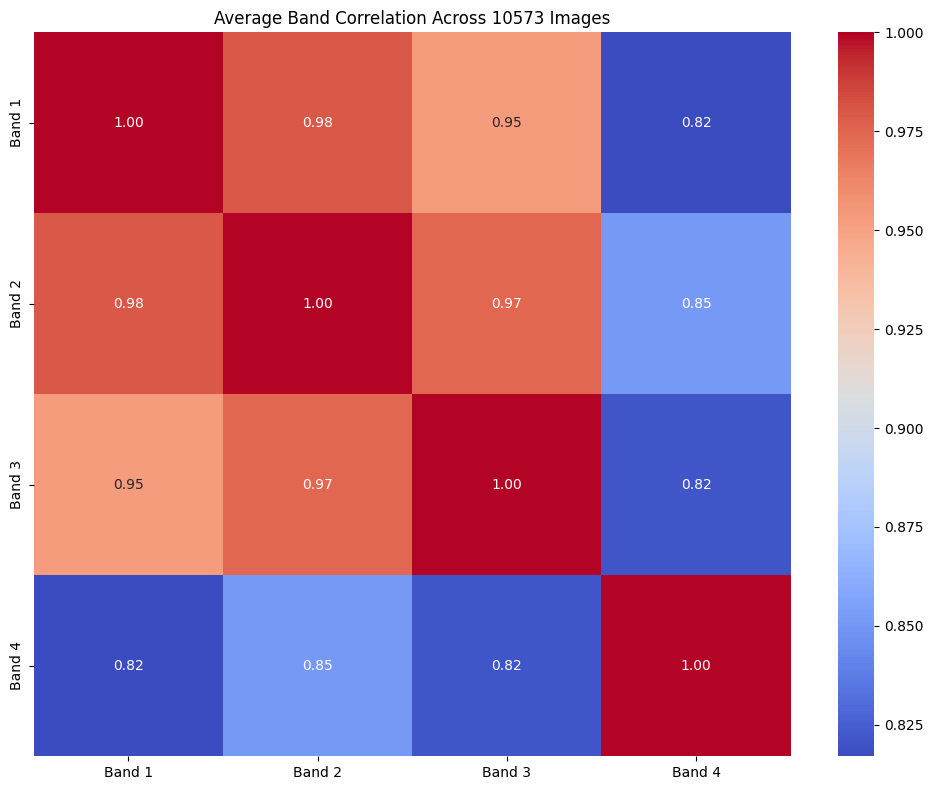

In [9]:
import os
import numpy as np
from osgeo import gdal
from tqdm import tqdm  # For progress bar

image_dir = '/kaggle/input/cloud-masking-dataset/content/train/data'
image_files = [f for f in os.listdir(image_dir) if f.endswith('.tif')]

sum_corr_matrix = None
valid_images = 0

for f in tqdm(image_files, desc="Processing images"):
    image_path = os.path.join(image_dir, f)
    ds = gdal.Open(image_path, gdal.GA_ReadOnly)
    img_array = ds.ReadAsArray()

    if img_array.ndim != 3:
        continue  # Skip malformed images

    bands, H, W = img_array.shape
    flattened = img_array.reshape(bands, -1)

    # Check if there's enough variation (to avoid NaNs)
    if np.std(flattened, axis=1).min() < 1e-5:
        continue

    corr_matrix = np.corrcoef(flattened)
    if sum_corr_matrix is None:
        sum_corr_matrix = corr_matrix
    else:
        sum_corr_matrix += corr_matrix

    valid_images += 1

# Average correlation matrix
avg_corr_matrix = sum_corr_matrix / valid_images

# Optional: Print or visualize
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(avg_corr_matrix, annot=True, fmt=".2f", cmap='coolwarm',
            xticklabels=[f'Band {i+1}' for i in range(bands)],
            yticklabels=[f'Band {i+1}' for i in range(bands)])
plt.title(f'Average Band Correlation Across {valid_images} Images')
plt.tight_layout()
plt.show()

### Checking Number of bands in images

In [10]:
import os
from collections import defaultdict
from osgeo import gdal

# Enable GDAL exceptions
gdal.UseExceptions()
gdal.AllRegister()

# Path to the folder containing your .tif images
image_dir = '/kaggle/input/cloud-masking-dataset/content/train/data'

# Dictionary to hold the count of each band number
band_counts = defaultdict(int)

# Loop through all files in the directory
for filename in os.listdir(image_dir):
    if filename.endswith('.tif'):
        filepath = os.path.join(image_dir, filename)
        try:
            img_ds = gdal.Open(filepath, gdal.GA_ReadOnly)
            if img_ds is None:
                continue
            num_bands = img_ds.RasterCount
            band_counts[num_bands] += 1
        except Exception as e:
            print(f"Error reading {filename}: {str(e)}")

# Print summary
print("Summary of number of images by band count:")
for bands, count in sorted(band_counts.items()):
    print(f"{count} image(s) with {bands} band(s)")

Summary of number of images by band count:
10573 image(s) with 4 band(s)


### Picking a random sample to see

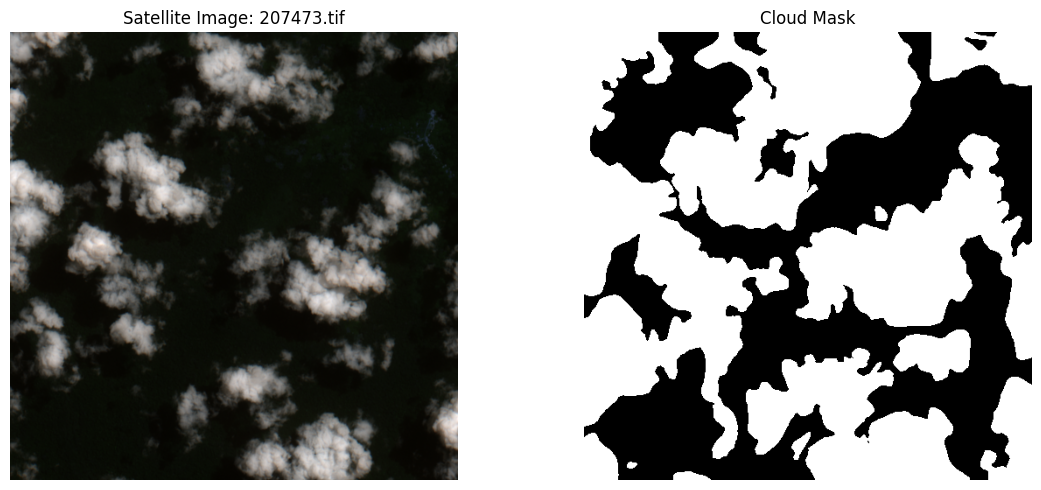

In [31]:
import os
import random
from osgeo import gdal
import matplotlib.pyplot as plt

# Paths
image_dir = '/kaggle/input/cloud-masking-dataset/content/train/data'
mask_dir = '/kaggle/input/cloud-masking-dataset/content/train/masks'

# List all image filenames
image_files = [f for f in os.listdir(image_dir) if f.endswith('.tif')]

# Pick a random one
sample_file = random.choice(image_files)
image_path = os.path.join(image_dir, sample_file)
mask_path = os.path.join(mask_dir, sample_file)

# Open image
img_ds = gdal.Open(image_path, gdal.GA_ReadOnly)
num_bands = img_ds.RasterCount

# Read bands (RGB or first 3 bands)
bands_to_read = min(num_bands, 3)
image_data = [img_ds.GetRasterBand(i + 1).ReadAsArray() for i in range(bands_to_read)]
rgb = np.dstack(image_data)

# Normalize for display
rgb_norm = (rgb - rgb.min()) / (rgb.max() - rgb.min())

# Open mask
mask_ds = gdal.Open(mask_path, gdal.GA_ReadOnly)
mask = mask_ds.GetRasterBand(1).ReadAsArray()

# Plot
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.title(f"Satellite Image: {sample_file}")
plt.imshow(rgb_norm)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Cloud Mask")
# To prevent making everything look black if all values are near zero.
plt.imshow(mask, cmap='gray', vmin=0, vmax=1)
plt.axis('off')

plt.tight_layout()
plt.show()
## cloud --> WHITE

### Data Split

In [12]:
import os
from sklearn.model_selection import train_test_split
import random
import numpy as np
import torch
from torch.utils.data import random_split

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Define original paths
image_dir = '/kaggle/input/cloud-masking-dataset/content/train/data'
mask_dir = '/kaggle/input/cloud-masking-dataset/content/train/masks'

# Get image–mask pairs
image_files = [f for f in os.listdir(image_dir) if f.endswith('.tif')]
paired_files = [f for f in image_files if os.path.exists(os.path.join(mask_dir, f))]

# Split data
train_size = int(0.8 * len(paired_files))
test_size = len(paired_files) - train_size

train_files, test_files = random_split(
    paired_files,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42)  # <--- fixed seed
)
# Let's say you want 80% train and 20% val from the training set
val_ratio = 0.2
val_size = int(val_ratio * len(train_files))
train_size = len(train_files) - val_size

train_subfiles, val_subfiles = random_split(
    train_files,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)  # fixed seed
)

# Create full paths for training and validation
train_image_paths = [os.path.join(image_dir, f) for f in train_subfiles]
train_mask_paths = [os.path.join(mask_dir, f) for f in train_subfiles]

val_image_paths = [os.path.join(image_dir, f) for f in val_subfiles]
val_mask_paths = [os.path.join(mask_dir, f) for f in val_subfiles]

# train_files, test_files = train_test_split(paired_files, test_size=0.2, random_state=42)

test_image_paths = [os.path.join(image_dir, f) for f in test_files]
test_mask_paths = [os.path.join(mask_dir, f) for f in test_files]

print(f"Train images: {len(train_image_paths)}, Test images: {len(test_image_paths)}")

Train images: 6767, Test images: 2115


### Data Loading

In [13]:
import os
import torch
import numpy as np
from osgeo import gdal
from torch.utils.data import Dataset, DataLoader
class CloudSegmentationDataset(Dataset):
    def __init__(self, image_paths, mask_paths):
        self.image_paths = image_paths
        self.mask_paths = mask_paths

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Load image
        img_ds = gdal.Open(self.image_paths[idx], gdal.GA_ReadOnly)
        img_array = img_ds.ReadAsArray()  # Shape: (bands, H, W)
         # Use only the first channel (band 0) → shape becomes (H, W)
        img_array = img_array[0]  # If you want a different channel, change the index    
        img_array = np.expand_dims(img_array, axis=0)
        
        image_tensor = torch.tensor(img_array, dtype=torch.float32)

        # Load mask
        mask_ds = gdal.Open(self.mask_paths[idx], gdal.GA_ReadOnly)
        mask_array = mask_ds.ReadAsArray()  # Shape: (H, W)
        mask_tensor = torch.tensor(mask_array, dtype=torch.long)

        return image_tensor, mask_tensor

In [14]:
train_dataset = CloudSegmentationDataset(train_image_paths, train_mask_paths)
val_dataset = CloudSegmentationDataset(val_image_paths, val_mask_paths)
test_dataset = CloudSegmentationDataset(test_image_paths, test_mask_paths)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print(f"{len(train_dataset)} training samples")
print(f"{len(val_dataset)} Validation samples")
print(f"{len(test_dataset)} testing samples")

6767 training samples
1691 Validation samples
2115 testing samples


### Model Initialization

In [37]:
# import torch.nn as nn
# import torch.nn.functional as F

# class UNet(nn.Module):
#     def __init__(self, in_channels=4, out_channels=2):
#         super(UNet, self).__init__()

#         def conv_block(in_c, out_c):
#             return nn.Sequential(
#                 nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
#                 nn.BatchNorm2d(out_c),
#                 nn.ReLU(inplace=True),
#                 nn.Conv2d(out_c, out_c, kernel_size=3, padding=1),
#                 nn.BatchNorm2d(out_c),
#                 nn.ReLU(inplace=True),
#             )

#         self.encoder1 = conv_block(in_channels, 64)
#         self.encoder2 = conv_block(64, 128)
#         self.encoder3 = conv_block(128, 256)
#         self.encoder4 = conv_block(256, 512)

#         self.pool = nn.MaxPool2d(2)

#         self.bottleneck = conv_block(512, 1024)

#         self.upconv4 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
#         self.decoder4 = conv_block(1024, 512)

#         self.upconv3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
#         self.decoder3 = conv_block(512, 256)

#         self.upconv2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
#         self.decoder2 = conv_block(256, 128)

#         self.upconv1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
#         self.decoder1 = conv_block(128, 64)

#         self.final_conv = nn.Conv2d(64, out_channels, kernel_size=1)

#     def forward(self, x):
#         # Encoder
#         e1 = self.encoder1(x)
#         e2 = self.encoder2(self.pool(e1))
#         e3 = self.encoder3(self.pool(e2))
#         e4 = self.encoder4(self.pool(e3))

#         b = self.bottleneck(self.pool(e4))

#         # Decoder
#         d4 = self.upconv4(b)
#         d4 = torch.cat((d4, e4), dim=1)
#         d4 = self.decoder4(d4)

#         d3 = self.upconv3(d4)
#         d3 = torch.cat((d3, e3), dim=1)
#         d3 = self.decoder3(d3)

#         d2 = self.upconv2(d3)
#         d2 = torch.cat((d2, e2), dim=1)
#         d2 = self.decoder2(d2)

#         d1 = self.upconv1(d2)
#         d1 = torch.cat((d1, e1), dim=1)
#         d1 = self.decoder1(d1)

#         return self.final_conv(d1)
# 
# B: Batch size — the number of images in one batch.
# C: Number of classes — the number of output channels (e.g., 2 classes, so C=2).
# H: Height — the spatial height of the image.
# W: Width — the spatial width of the image.

import torch
import torch.nn as nn
import torch.nn.functional as F

class LeNet5Segmentation(nn.Module):
    def __init__(self, in_channels, num_classes=2):  # 2 classes: cloud / no-cloud
        super(LeNet5Segmentation, self).__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels, 6, kernel_size=5, padding=2),  # [B, 6, H, W]
            nn.ReLU(),
            nn.AvgPool2d(2),  # [B, 6, H/2, W/2]

            nn.Conv2d(6, 16, kernel_size=5, padding=2),  # [B, 16, H/2, W/2]
            nn.ReLU(),
            nn.AvgPool2d(2)   # [B, 16, H/4, W/4]
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(16, 6, kernel_size=2, stride=2),  # [B, 6, H/2, W/2]
            nn.ReLU(),

            nn.ConvTranspose2d(6, num_classes, kernel_size=2, stride=2),  # [B, num_classes, H, W]
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)  # Output shape: [B, num_classes, H, W]
        return x

# Instantiate
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LeNet5Segmentation(in_channels=1, num_classes=2).to(device)
model = torch.nn.DataParallel(model)
print(model)

DataParallel(
  (module): LeNet5Segmentation(
    (encoder): Sequential(
      (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
      (1): ReLU()
      (2): AvgPool2d(kernel_size=2, stride=2, padding=0)
      (3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
      (4): ReLU()
      (5): AvgPool2d(kernel_size=2, stride=2, padding=0)
    )
    (decoder): Sequential(
      (0): ConvTranspose2d(16, 6, kernel_size=(2, 2), stride=(2, 2))
      (1): ReLU()
      (2): ConvTranspose2d(6, 2, kernel_size=(2, 2), stride=(2, 2))
    )
  )
)


In [16]:
import torch.optim as optim

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# model = UNet(in_channels=1, out_channels=2).to(device)
# model = torch.nn.DataParallel(model)
# criterion = nn.CrossEntropyLoss()  # masks must be LongTensor (not one-hot!)
# optimizer = optim.Adam(model.parameters(), lr=0.005)

In [33]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

# Assume model, train_loader, val_loader, device are already defined
num_classes = 2  # change this if you have more classes

# ----------------- Metric Functions -----------------
def pixel_accuracy(preds, labels):
    preds = torch.argmax(preds, dim=1)
    correct = (preds == labels).float()
    return correct.sum() / correct.numel()

def dice_coefficient(preds, labels, smooth=1e-6):
    # Dice= 2⋅∣A∩B∣
    #       ------
    #       ∣A∣+∣B∣
    preds = torch.argmax(preds, dim=1)
    dice = 0.0
    for c in range(num_classes):
        pred_c = (preds == c).float()
        label_c = (labels == c).float()
        intersection = (pred_c * label_c).sum()
        dice += (2. * intersection + smooth) / (pred_c.sum() + label_c.sum() + smooth)
    return dice / num_classes

def mean_iou(preds, labels, num_classes):
    preds = torch.argmax(preds, dim=1)
    ious = []
    for cls in range(num_classes):
        pred_inds = (preds == cls)
        target_inds = (labels == cls)
        intersection = (pred_inds & target_inds).sum().float()
        union = (pred_inds | target_inds).sum().float()
        if union == 0:
            ious.append(float('nan'))  # avoid division by zero
        else:
            ious.append((intersection / union).item())
    ious = [iou for iou in ious if not np.isnan(iou)]
    return sum(ious) / len(ious) if ious else 0.0
def train_model(model, train_loader, criterion, optimizer, epochs=10):
    for epoch in range(epochs):
        model.train()
        total_loss, total_acc, total_dice, total_iou = 0.0, 0.0, 0.0, 0.0
        total_batches = 0

        for images, masks in train_loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)

            loss = criterion(outputs, masks)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            acc = pixel_accuracy(outputs, masks)
            dice = dice_coefficient(outputs, masks)
            iou = mean_iou(outputs, masks, num_classes)

            total_loss += loss.item()
            total_acc += acc.item()
            total_dice += dice
            total_iou += iou
            total_batches += 1

        print(f"Epoch [{epoch+1}/{epochs}] | Loss: {total_loss/total_batches:.4f} | "
              f"Pixel Acc: {total_acc/total_batches:.4f} | "
              f"Dice: {total_dice/total_batches:.4f} | IoU: {total_iou/total_batches:.4f}")
    
    return total_loss/total_batches, total_dice/total_batches,model

In [18]:
def evaluate_model(model, loader, split="Validation"):
    model.eval()
    total_acc, total_dice, total_iou = 0.0, 0.0, 0.0
    total_batches = 0

    with torch.no_grad():
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)

            acc = pixel_accuracy(outputs, masks)
            dice = dice_coefficient(outputs, masks)
            iou = mean_iou(outputs, masks, num_classes)

            total_acc += acc.item()
            total_dice += dice
            total_iou += iou
            total_batches += 1

    avg_acc = total_acc / total_batches
    avg_dice = total_dice / total_batches
    avg_iou = total_iou / total_batches

    print(f"{split} Results - Acc: {avg_acc:.4f} | **Dice**: {avg_dice:.4f} | IoU: {avg_iou:.4f}")
    return avg_acc, avg_dice, avg_iou

In [40]:
# Tracking best metrics
best_dice = 0.0
best_model_params = None
best_hyperparams = {}
learning_rate_list = [0.001, 0.01, 0.0005, 0.1]
num_epochs_list = [20]
criterion = nn.CrossEntropyLoss()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
for num_epochs in num_epochs_list:
    for learning_rate in learning_rate_list:
        print(f"\n======== Training with epochs={num_epochs}, lr={learning_rate} ========")
        model = LeNet5Segmentation(in_channels=1, num_classes=2).to(device)
        model = torch.nn.DataParallel(model)
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)
        loss,dice,model = train_model(model, train_loader, criterion, optimizer, num_epochs)
        print(f"Loss: {loss:.4f} | Dice: {dice:.4f}")
        _, val_dice, _ = evaluate_model(model, val_loader, split="Validation")
    
        if val_dice > best_dice:
            best_dice = val_dice
            best_model_params = model.state_dict()
            best_hyperparams = {"epochs": num_epochs, "learning_rate": learning_rate}
            torch.save(best_model_params, "best_model.pth")

        print("****************************************")

print("Best Hyperparameters:", best_hyperparams)


======== Training with epochs=20, lr=0.001 ========
Epoch [1/20] | Loss: 0.7745 | Pixel Acc: 0.6059 | Dice: 0.3826 | IoU: 0.3064
Epoch [2/20] | Loss: 0.4920 | Pixel Acc: 0.6937 | Dice: 0.5433 | IoU: 0.4416
Epoch [3/20] | Loss: 0.4289 | Pixel Acc: 0.8345 | Dice: 0.8117 | IoU: 0.6947
Epoch [4/20] | Loss: 0.4079 | Pixel Acc: 0.8451 | Dice: 0.8321 | IoU: 0.7200
Epoch [5/20] | Loss: 0.3990 | Pixel Acc: 0.8455 | Dice: 0.8332 | IoU: 0.7209
Epoch [6/20] | Loss: 0.3922 | Pixel Acc: 0.8464 | Dice: 0.8346 | IoU: 0.7233
Epoch [7/20] | Loss: 0.3905 | Pixel Acc: 0.8450 | Dice: 0.8342 | IoU: 0.7223
Epoch [8/20] | Loss: 0.3900 | Pixel Acc: 0.8466 | Dice: 0.8352 | IoU: 0.7242
Epoch [9/20] | Loss: 0.3933 | Pixel Acc: 0.8426 | Dice: 0.8314 | IoU: 0.7186
Epoch [10/20] | Loss: 0.3903 | Pixel Acc: 0.8438 | Dice: 0.8327 | IoU: 0.7202
Epoch [11/20] | Loss: 0.3880 | Pixel Acc: 0.8460 | Dice: 0.8360 | IoU: 0.7246
Epoch [12/20] | Loss: 0.3841 | Pixel Acc: 0.8466 | Dice: 0.8372 | IoU: 0.7263
Epoch [13/20] | Loss

### Evaluation

In [41]:
# Define the same model architecture
model = LeNet5Segmentation(in_channels=1, num_classes=2).to(device)
model = torch.nn.DataParallel(model)

# Load saved parameters
model.load_state_dict(torch.load("best_model.pth"))

# Now you can use this model for validation or inference
test_acc, test_dice, test_iou = evaluate_model(model, test_loader, split="Test")
print(f"Loaded best model → Validation Dice: {test_dice:.4f}")

/tmp/ipykernel_31/9615280.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model.pth"))


Test Results - Acc: 0.8478 | **Dice**: 0.8377 | IoU: 0.7276
Loaded best model → Validation Dice: 0.8377
